In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print(tf.config.list_physical_devices())


2025-12-04 14:20:59.529988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764876059.541345 4187630 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764876059.544852 4187630 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764876059.554487 4187630 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764876059.554498 4187630 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764876059.554499 4187630 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-12-04 14:21:01.783392: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-04 14:21:01.783417: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-12-04 14:21:01.783422: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-12-04 14:21:01.783424: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-04 14:21:01.783428: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: gokhan-Lambda-Vector
2025-12-04 14:21:01.783430: I external/local_xla/xla/stream_execut

In [ ]:
import pandas as pd

# Load the dataset
unsw = pd.read_csv("UNSW_NB15_testing-set.csv")

# List unique labels in 'attack_cat'
unique_labels = unsw['attack_cat'].unique()
print("Unique UNSW attack_cat labels:")
print(unique_labels)


Unique UNSW attack_cat labels:
['Normal' 'Reconnaissance' 'Backdoor' 'DoS' 'Exploits' 'Analysis'
 'Fuzzers' 'Worms' 'Shellcode' 'Generic']


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, Input, ReLU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import tensorflow as tf

# -------------------------------
# 1. LOAD UNSW DATASET
# -------------------------------
unsw = pd.read_csv("UNSW_NB15_testing-set.csv")
unsw.columns = unsw.columns.str.strip()

if "attack_cat" in unsw.columns:
    unsw.rename(columns={"attack_cat": "Label"}, inplace=True)

# -------------------------------
# 2. DEFINE KNOWN & UNKNOWN CLASSES
# -------------------------------
known_classes = ["Normal", "DoS", "Fuzzers", "Generic", "Reconnaissance", "Exploits"]
zero_day_classes = ["Analysis", "Shellcode", "Worms", "Backdoor"]

unsw_known = unsw[unsw["Label"].isin(known_classes)].copy()
unsw_unknown = unsw[unsw["Label"].isin(zero_day_classes)].copy()
unsw_unknown["Label"] = "Unknown"

# -------------------------------
# 3. BALANCE KNOWN CLASSES
# -------------------------------
TARGET = 5999
balanced_known = []

for cls in known_classes:
    df_cls = unsw_known[unsw_known["Label"] == cls]
    sampled = df_cls.sample(n=min(TARGET, len(df_cls)), random_state=42)
    balanced_known.append(sampled)

known_df = pd.concat(balanced_known, ignore_index=True)
unknown_df = unsw_unknown.copy()

print("Balanced Known Class Counts:\n", known_df["Label"].value_counts())
print("Unknown Class Count:", unknown_df.shape[0])

# -------------------------------
# 4. BASIC PREPROCESSING (NUMERIC ONLY)
# -------------------------------
numeric_cols = known_df.select_dtypes(include=[np.number]).columns.tolist()
known_df[numeric_cols] = known_df[numeric_cols].replace([np.inf, -np.inf], np.nan)
unknown_df[numeric_cols] = unknown_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Fill NaN only in numeric columns
for col in numeric_cols:
    mean_val = known_df[col].mean()
    known_df[col] = known_df[col].fillna(mean_val)
    unknown_df[col] = unknown_df[col].fillna(mean_val)

# -------------------------------
# 5. REMOVE ZERO-VARIANCE FEATURES
# -------------------------------
X_known = known_df[numeric_cols].copy()
X_unknown = unknown_df[numeric_cols].copy()

selector = VarianceThreshold(threshold=0)
X_known = X_known.loc[:, selector.fit(X_known).get_support()]
X_unknown = X_unknown[X_known.columns]

# -------------------------------
# 6. FEATURE SCALING
# -------------------------------
skewed_cols = [col for col in ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                                'Fwd IAT Total', 'Bwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s',
                                'Fwd IAT Max', 'Bwd IAT Max', 'Max Packet Length'] if col in X_known.columns]

if skewed_cols:
    mms = MinMaxScaler()
    X_known[skewed_cols] = mms.fit_transform(X_known[skewed_cols])
    X_unknown[skewed_cols] = mms.transform(X_unknown[skewed_cols])

standard_cols = [col for col in X_known.columns if col not in skewed_cols]
if standard_cols:
    ss = StandardScaler()
    X_known[standard_cols] = ss.fit_transform(X_known[standard_cols])
    X_unknown[standard_cols] = ss.transform(X_unknown[standard_cols])

# Clip extreme outliers
for col in X_known.columns:
    lower, upper = X_known[col].quantile([0.01, 0.99])
    X_known[col] = X_known[col].clip(lower=lower, upper=upper)
    X_unknown[col] = X_unknown[col].clip(lower=lower, upper=upper)

# -------------------------------
# 7. LABEL ENCODING (6 known + 1 unknown)
# -------------------------------
le = LabelEncoder()
le.fit(known_classes + ["Unknown"])

y_known_encoded = le.transform(known_df['Label'])
y_unknown_encoded = le.transform(unknown_df['Label'])

# -------------------------------
# 8. SPLIT TRAIN/TEST
# -------------------------------
X_train, X_test_known, y_train, y_test_known = train_test_split(
    X_known,
    y_known_encoded,
    test_size=0.2,
    stratify=y_known_encoded,
    random_state=42
)

X_test = pd.concat([X_test_known, X_unknown], axis=0)
y_test = np.concatenate([y_test_known, y_unknown_encoded])

# -------------------------------
# 9. ONE-HOT ENCODE (7 classes)
# -------------------------------
num_classes = len(le.classes_)  # 7
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=num_classes-1)  # known classes only for training
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)       # test includes unknown

print("Number of classes (one-hot):", num_classes)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

# -------------------------------
# 10. RESHAPE FOR CNN
# -------------------------------
X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1).astype(np.float32)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1).astype(np.float32)

# -------------------------------
# 11. DEBUG
# -------------------------------
print(f"X_train_cnn: {X_train_cnn.shape}, NaN/Inf: {np.isnan(X_train_cnn).sum() + np.isinf(X_train_cnn).sum()}")
print(f"X_test_cnn: {X_test_cnn.shape}, NaN/Inf: {np.isnan(X_test_cnn).sum() + np.isinf(X_test_cnn).sum()}")
print(f"y_train_cat: {y_train_cat.shape}, y_test_cat: {y_test_cat.shape}")


Balanced Known Class Counts:
 Label
Normal            5999
Fuzzers           5999
Generic           5999
Exploits          5999
DoS               4089
Reconnaissance    3496
Name: count, dtype: int64
Unknown Class Count: 1682
Number of classes (one-hot): 7
y_train_cat shape: (25264, 6)
y_test_cat shape: (7999, 7)
X_train_cnn: (25264, 41, 1), NaN/Inf: 0
X_test_cnn: (7999, 41, 1), NaN/Inf: 0
y_train_cat: (25264, 6), y_test_cat: (7999, 7)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Step: Compute class weights for known classes only (0–5)
known_class_indices = np.arange(len(known_classes))  # 0 to 5

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=known_class_indices,
    y=y_train  # only training labels (known classes)
)

# Convert to dictionary for Keras
class_weights = dict(zip(known_class_indices, class_weights_array))

print(f"Computed class weights (known classes only): {class_weights}")


Computed class weights (known classes only): {0: 1.2872719861408335, 1: 0.8774050149336667, 2: 0.8774050149336667, 3: 0.8774050149336667, 4: 0.8774050149336667, 5: 1.505422476462877}


In [ ]:
# Encode only known classes for training
le_known = LabelEncoder()
le_known.fit(known_classes)

y_train_encoded = le_known.transform(known_df['Label'])
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(known_classes))


In [ ]:
# Step 0: Before defining the CNN model
num_classes_train = y_train_cat.shape[1]  # Number of classes in training (known classes only)
input_shape = (X_train_cnn.shape[1], 1)  # Features × 1 (for CNN input)

print(f"Number of training classes: {num_classes_train}")
print(f"CNN input shape: {input_shape}")


Number of training classes: 6
CNN input shape: (41, 1)


In [ ]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import numpy as np

# 1. Encode known classes only
le_known = LabelEncoder()
le_known.fit(known_classes)

y_train_encoded = le_known.transform(known_df['Label'].iloc[X_train.index])
y_test_known_encoded = le_known.transform(known_df['Label'].iloc[X_test_known.index])

# 2. One-hot encode
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=len(known_classes))
y_test_known_cat = tf.keras.utils.to_categorical(y_test_known_encoded, num_classes=len(known_classes))

# 3. Combine with unknowns for full test set
y_unknown_encoded = len(known_classes) * np.ones(unknown_df.shape[0], dtype=int)  # 'Unknown' index
y_test_cat = tf.keras.utils.to_categorical(
    np.concatenate([y_test_known_encoded, y_unknown_encoded]),
    num_classes=len(known_classes) + 1  # 7 classes total
)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, ReLU, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


In [ ]:
# Step 0: Before model definition
num_classes_train = y_train_cat.shape[1]  # Should be 10 known classes
input_shape = (X_train_cnn.shape[1], 1)

# Step 10: CNN with reduced capacity
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, ReLU, BatchNormalization, MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

inputs = Input(shape=input_shape)

# Conv Block 1
x = Conv1D(filters=8, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(inputs)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Conv Block 2
x = Conv1D(filters=24, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Conv Block 3
x = Conv1D(filters=32, kernel_size=3, padding='same', kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# Dense layers
x = GlobalAveragePooling1D()(x)
x = Dense(48, kernel_regularizer=l2(0.005))(x)
x = ReLU()(x)
x = Dropout(0.5)(x)

# Output layer: only 10 known classes
outputs = Dense(num_classes_train, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Custom loss with entropy to encourage smoother output
def custom_loss_with_entropy(y_true, y_pred):
    cross_entropy = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1 - epsilon)
    entropy = -tf.reduce_sum(y_pred * tf.math.log(y_pred), axis=-1)
    return cross_entropy + 1.0 * entropy

model.compile(
    optimizer=Adam(learning_rate=1e-5, clipnorm=1.0),
    loss=custom_loss_with_entropy,
    metrics=['accuracy']
)

# Debug: Check initial loss
initial_loss = model.evaluate(X_train_cnn, y_train_cat, batch_size=1000, verbose=0)[0]
print(f"Initial loss: {initial_loss}")




Initial loss: 3.973799467086792


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Step 11: Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=800,
    batch_size=500,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)


Epoch 1/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.1795 - loss: 4.0135 - val_accuracy: 0.1435 - val_loss: 3.9795 - learning_rate: 1.0000e-05
Epoch 2/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1923 - loss: 3.9816 - val_accuracy: 0.1360 - val_loss: 3.9859 - learning_rate: 1.0000e-05
Epoch 3/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1910 - loss: 3.9713 - val_accuracy: 0.1369 - val_loss: 3.9871 - learning_rate: 1.0000e-05
Epoch 4/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1971 - loss: 3.9423 - val_accuracy: 0.1457 - val_loss: 3.9818 - learning_rate: 1.0000e-05
Epoch 5/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2011 - loss: 3.9386 - val_accuracy: 0.1559 - val_loss: 3.9704 - learning_rate: 1.0000e-05
Epoch 6/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2181 - loss: 3.9071 - val_accuracy: 0.1708 - val_loss: 3.9529 - learning_rate: 1.0000e-05
Epoch 7/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 

Epoch 44/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4435 - loss: 3.2627 - val_accuracy: 0.5143 - val_loss: 3.1084 - learning_rate: 1.0000e-05
Epoch 45/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4353 - loss: 3.2733 - val_accuracy: 0.5173 - val_loss: 3.0916 - learning_rate: 1.0000e-05
Epoch 46/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4472 - loss: 3.2312 - val_accuracy: 0.5195 - val_loss: 3.0751 - learning_rate: 1.0000e-05
Epoch 47/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4406 - loss: 3.2476 - val_accuracy: 0.5213 - val_loss: 3.0584 - learning_rate: 1.0000e-05
Epoch 48/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4519 - loss: 3.2207 - val_accuracy: 0.5254 - val_loss: 3.0416 - learning_rate: 1.0000e-05
Epoch 49/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4574 - loss: 3.2139 - val_accuracy: 0.5286 - val_loss: 3.0255 - learning_rate: 1.0000e-05
Epoch 50/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc

Epoch 87/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5602 - loss: 2.7390 - val_accuracy: 0.6093 - val_loss: 2.4658 - learning_rate: 1.0000e-05
Epoch 88/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5599 - loss: 2.7284 - val_accuracy: 0.6109 - val_loss: 2.4539 - learning_rate: 1.0000e-05
Epoch 89/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5626 - loss: 2.6978 - val_accuracy: 0.6123 - val_loss: 2.4419 - learning_rate: 1.0000e-05
Epoch 90/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5565 - loss: 2.7081 - val_accuracy: 0.6129 - val_loss: 2.4303 - learning_rate: 1.0000e-05
Epoch 91/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5658 - loss: 2.6825 - val_accuracy: 0.6137 - val_loss: 2.4189 - learning_rate: 1.0000e-05
Epoch 92/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5646 - loss: 2.6762 - val_accuracy: 0.6161 - val_loss: 2.4073 - learning_rate: 1.0000e-05
Epoch 93/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc

Epoch 130/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6494 - loss: 2.3471 - val_accuracy: 0.7097 - val_loss: 2.0297 - learning_rate: 1.0000e-05
Epoch 131/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6522 - loss: 2.3146 - val_accuracy: 0.7107 - val_loss: 2.0209 - learning_rate: 1.0000e-05
Epoch 132/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6495 - loss: 2.3241 - val_accuracy: 0.7117 - val_loss: 2.0128 - learning_rate: 1.0000e-05
Epoch 133/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6570 - loss: 2.3164 - val_accuracy: 0.7121 - val_loss: 2.0051 - learning_rate: 1.0000e-05
Epoch 134/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6593 - loss: 2.2983 - val_accuracy: 0.7150 - val_loss: 1.9968 - learning_rate: 1.0000e-05
Epoch 135/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6609 - loss: 2.2947 - val_accuracy: 0.7174 - val_loss: 1.9884 - learning_rate: 1.0000e-05
Epoch 136/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

Epoch 173/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6988 - loss: 2.0484 - val_accuracy: 0.7356 - val_loss: 1.7462 - learning_rate: 1.0000e-05
Epoch 174/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6901 - loss: 2.0685 - val_accuracy: 0.7358 - val_loss: 1.7415 - learning_rate: 1.0000e-05
Epoch 175/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6952 - loss: 2.0523 - val_accuracy: 0.7366 - val_loss: 1.7367 - learning_rate: 1.0000e-05
Epoch 176/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6994 - loss: 2.0453 - val_accuracy: 0.7372 - val_loss: 1.7320 - learning_rate: 1.0000e-05
Epoch 177/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6960 - loss: 2.0567 - val_accuracy: 0.7372 - val_loss: 1.7283 - learning_rate: 1.0000e-05
Epoch 178/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7001 - loss: 2.0271 - val_accuracy: 0.7372 - val_loss: 1.7231 - learning_rate: 1.0000e-05
Epoch 179/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

...

Epoch 603/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7934 - loss: 1.3427 - val_accuracy: 0.7964 - val_loss: 1.1749 - learning_rate: 1.0000e-05
Epoch 604/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7854 - loss: 1.3776 - val_accuracy: 0.7970 - val_loss: 1.1740 - learning_rate: 1.0000e-05
Epoch 605/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7912 - loss: 1.3623 - val_accuracy: 0.7973 - val_loss: 1.1734 - learning_rate: 1.0000e-05
Epoch 606/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7899 - loss: 1.3522 - val_accuracy: 0.7975 - val_loss: 1.1734 - learning_rate: 1.0000e-05
Epoch 607/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7876 - loss: 1.3512 - val_accuracy: 0.7973 - val_loss: 1.1732 - learning_rate: 1.0000e-05
Epoch 608/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7905 - loss: 1.3590 - val_accuracy: 0.7964 - val_loss: 1.1731 - learning_rate: 1.0000e-05
Epoch 609/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

Epoch 646/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7882 - loss: 1.3356 - val_accuracy: 0.8013 - val_loss: 1.1557 - learning_rate: 1.0000e-05
Epoch 647/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7922 - loss: 1.3270 - val_accuracy: 0.8013 - val_loss: 1.1552 - learning_rate: 1.0000e-05
Epoch 648/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7902 - loss: 1.3231 - val_accuracy: 0.8005 - val_loss: 1.1558 - learning_rate: 1.0000e-05
Epoch 649/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7922 - loss: 1.3331 - val_accuracy: 0.8015 - val_loss: 1.1546 - learning_rate: 1.0000e-05
Epoch 650/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7932 - loss: 1.3246 - val_accuracy: 0.8013 - val_loss: 1.1546 - learning_rate: 1.0000e-05
Epoch 651/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7928 - loss: 1.3333 - val_accuracy: 0.8011 - val_loss: 1.1546 - learning_rate: 1.0000e-05
Epoch 652/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

Epoch 689/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7908 - loss: 1.3098 - val_accuracy: 0.8035 - val_loss: 1.1389 - learning_rate: 1.0000e-05
Epoch 690/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7922 - loss: 1.3255 - val_accuracy: 0.8035 - val_loss: 1.1381 - learning_rate: 1.0000e-05
Epoch 691/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7906 - loss: 1.3402 - val_accuracy: 0.8041 - val_loss: 1.1384 - learning_rate: 1.0000e-05
Epoch 692/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7958 - loss: 1.3062 - val_accuracy: 0.8041 - val_loss: 1.1375 - learning_rate: 1.0000e-05
Epoch 693/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8016 - loss: 1.2881 - val_accuracy: 0.8045 - val_loss: 1.1367 - learning_rate: 1.0000e-05
Epoch 694/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7976 - loss: 1.3071 - val_accuracy: 0.8043 - val_loss: 1.1373 - learning_rate: 1.0000e-05
Epoch 695/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

Epoch 732/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7941 - loss: 1.3003 - val_accuracy: 0.8057 - val_loss: 1.1224 - learning_rate: 1.0000e-05
Epoch 733/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7953 - loss: 1.2927 - val_accuracy: 0.8059 - val_loss: 1.1224 - learning_rate: 1.0000e-05
Epoch 734/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7971 - loss: 1.2814 - val_accuracy: 0.8061 - val_loss: 1.1218 - learning_rate: 1.0000e-05
Epoch 735/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7967 - loss: 1.2951 - val_accuracy: 0.8074 - val_loss: 1.1207 - learning_rate: 1.0000e-05
Epoch 736/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8023 - loss: 1.2656 - val_accuracy: 0.8070 - val_loss: 1.1211 - learning_rate: 1.0000e-05
Epoch 737/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7999 - loss: 1.2830 - val_accuracy: 0.8070 - val_loss: 1.1204 - learning_rate: 1.0000e-05
Epoch 738/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

Epoch 775/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8040 - loss: 1.2415 - val_accuracy: 0.8080 - val_loss: 1.1086 - learning_rate: 1.0000e-05
Epoch 776/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7970 - loss: 1.2763 - val_accuracy: 0.8078 - val_loss: 1.1076 - learning_rate: 1.0000e-05
Epoch 777/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7948 - loss: 1.2764 - val_accuracy: 0.8082 - val_loss: 1.1070 - learning_rate: 1.0000e-05
Epoch 778/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7992 - loss: 1.2595 - val_accuracy: 0.8084 - val_loss: 1.1069 - learning_rate: 1.0000e-05
Epoch 779/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7993 - loss: 1.2670 - val_accuracy: 0.8080 - val_loss: 1.1070 - learning_rate: 1.0000e-05
Epoch 780/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7957 - loss: 1.2731 - val_accuracy: 0.8076 - val_loss: 1.1070 - learning_rate: 1.0000e-05
Epoch 781/800
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

In [ ]:
# Step 12: Sanity check on labels
print("Train classes (unique):", np.unique(y_train))
print("Train one-hot shape:", y_train_cat.shape)
print("Total label classes (including unknown):", len(le.classes_))


Train classes (unique): [0 1 2 3 4 5]
Train one-hot shape: (25264, 6)
Total label classes (including unknown): 7


In [ ]:
# Step 13: Evaluate test metrics on known classes only
# Create mask for known classes in y_test
unknown_encoded = le.transform(['Unknown'])[0]
known_mask = y_test != unknown_encoded

# Select only known-class samples
X_test_known_cnn = X_test_cnn[known_mask]
y_test_known_cat = y_test_cat[known_mask]

# Predict
test_pred_known = model.predict(X_test_known_cnn)
test_pred_classes = np.argmax(test_pred_known, axis=1)
test_true_classes = np.argmax(y_test_known_cat, axis=1)

# Compute metrics
test_acc = accuracy_score(test_true_classes, test_pred_classes)
test_f1 = f1_score(test_true_classes, test_pred_classes, average='weighted')

print(f"Test accuracy (Known classes only): {test_acc:.4f}")
print(f"Test F1 score (Known classes only): {test_f1:.4f}")


198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test accuracy (Known classes only): 0.8078
Test F1 score (Known classes only): 0.8066


In [ ]:
true_labels = y_test
unknown_class_index = le.transform(["Unknown"])[0]

known_mask = true_labels != unknown_class_index
unknown_mask = true_labels == unknown_class_index

p_max_known = p_max[known_mask]
p_max_unknown = p_max[unknown_mask]

p1_p2_known = p1_minus_p2[known_mask]
p1_p2_unknown = p1_minus_p2[unknown_mask]

print(f"True known samples in test: {known_mask.sum()}")
print(f"True unknown samples in test: {unknown_mask.sum()}")


True known samples in test: 6317
True unknown samples in test: 1682


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
True known samples in test: 6317
True unknown samples in test: 1682

--- p_max Distribution ---
Known class p_max: 0.9078 ± 0.1392
Unknown class p_max: 0.7247 ± 0.1635
Known class p1-p2 diff: 0.8419 ± 0.2379
Unknown class p1-p2 diff: 0.5311 ± 0.2878


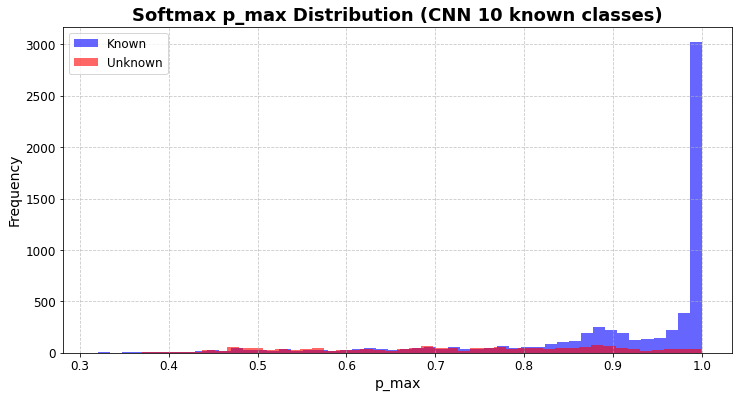

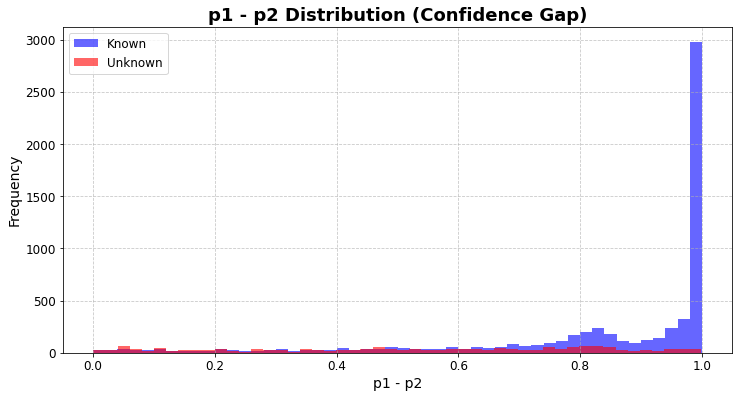

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get CNN predictions
cnn_probs = model.predict(X_test_cnn, batch_size=512, verbose=1)  # shape: (num_samples, 10)
cnn_preds = np.argmax(cnn_probs, axis=1)
p_max = np.max(cnn_probs, axis=1)

# Compute p1 - p2 for confidence gap
sorted_probs = np.sort(cnn_probs, axis=1)
p1_minus_p2 = sorted_probs[:, -1] - sorted_probs[:, -2]

# Step 2: Separate based on true labels
true_labels = y_test
known_mask = true_labels != 6  # known class mask
unknown_mask = true_labels == 6  # unknown class mask

p_max_known = p_max[known_mask]
p_max_unknown = p_max[unknown_mask]

p1_p2_known = p1_minus_p2[known_mask]
p1_p2_unknown = p1_minus_p2[unknown_mask]

# Step 3: Print Stats
print(f"True known samples in test: {known_mask.sum()}")
print(f"True unknown samples in test: {unknown_mask.sum()}")
print(f"\n--- p_max Distribution ---")
print(f"Known class p_max: {p_max_known.mean():.4f} ± {p_max_known.std():.4f}")
print(f"Unknown class p_max: {p_max_unknown.mean():.4f} ± {p_max_unknown.std():.4f}")
print(f"Known class p1-p2 diff: {p1_p2_known.mean():.4f} ± {p1_p2_known.std():.4f}")
print(f"Unknown class p1-p2 diff: {p1_p2_unknown.mean():.4f} ± {p1_p2_unknown.std():.4f}")

# Step 4: Plot Distributions
plt.figure(figsize=(12,6))

plt.hist(p_max_known, bins=50, alpha=0.6, label='Known', color='blue')
plt.hist(p_max_unknown, bins=50, alpha=0.6, label='Unknown', color='red')

plt.title("Softmax p_max Distribution (CNN 10 known classes)", fontsize=18, fontweight='bold')
plt.xlabel("p_max", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Optional: Plot p1-p2 distribution
plt.figure(figsize=(12,6))
plt.hist(p1_p2_known, bins=50, alpha=0.6, label='Known', color='blue')
plt.hist(p1_p2_unknown, bins=50, alpha=0.6, label='Unknown', color='red')
plt.title("p1 - p2 Distribution (Confidence Gap)", fontsize=18, fontweight='bold')
plt.xlabel("p1 - p2", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


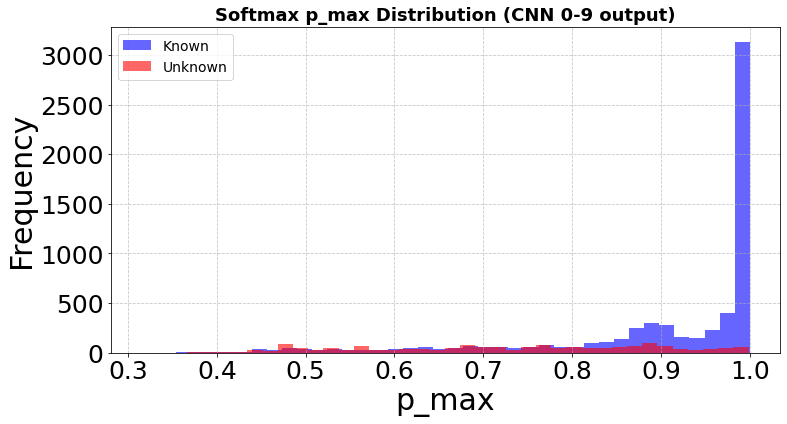

In [ ]:
# Step 5: Plot Distributions
plt.figure(figsize=(12,6))

# Increase histogram text size
plt.hist(p_max_known, bins=40, alpha=0.6, label='Known', color='blue')
plt.hist(p_max_unknown, bins=40, alpha=0.6, label='Unknown', color='red')

# Title and axis labels with bigger font
plt.title("Softmax p_max Distribution (CNN 0-9 output)", fontsize=18, fontweight='bold')
plt.xlabel("p_max", fontsize=30)
plt.ylabel("Frequency", fontsize=30)

# Bigger ticks (scale numbers on axes)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Legend with bigger font
plt.legend(fontsize=14)

# Grid
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


In [ ]:
# Step 1: Get softmax predictions from CNN
cnn_probs = model.predict(X_test_cnn)  # shape
true_labels = y_test                   # shape

# Step 2: Save softmax outputs and true labels as npy
np.save("cnn_softmax_outputs.npy", cnn_probs)
np.save("true_labels.npy", true_labels)

print("Saved 'cnn_softmax_outputs.npy' (shape:", cnn_probs.shape, ")")
print("Saved 'true_labels.npy' (shape:", true_labels.shape, ")")


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Saved 'cnn_softmax_outputs.npy' (shape: (7999, 6) )
Saved 'true_labels.npy' (shape: (7999,) )


In [ ]:
# Load saved outputs
softmax_outputs = np.load("cnn_softmax_outputs.npy")
true_labels = np.load("true_labels.npy")

# Get predicted labels (argmax)
predicted_labels = np.argmax(softmax_outputs, axis=1)

# Save as compressed .npz
np.savez("cnn_results_combined.npz",
         true_labels=true_labels,
         softmax_outputs=softmax_outputs,
         predicted_labels=predicted_labels)

print("Saved combined CNN results to 'cnn_results_combined.npz'")


Saved combined CNN results to 'cnn_results_combined.npz'


In [ ]:
# Verify saved file by loading it back
loaded_data = np.load("cnn_results_combined.npz")
print("Loaded arrays:", list(loaded_data.keys()))
print("True labels shape:", loaded_data['true_labels'].shape)
print("Softmax outputs shape:", loaded_data['softmax_outputs'].shape)
print("Predicted labels shape:", loaded_data['predicted_labels'].shape)
import numpy as np

# Load the .npz file
loaded_data = np.load("cnn_results_combined.npz")

# Get unique true labels
unique_true_labels = np.unique(loaded_data['true_labels'])
print("Unique true labels:", unique_true_labels)

# Get unique predicted labels
unique_predicted_labels = np.unique(loaded_data['predicted_labels'])
print("Unique predicted labels:", unique_predicted_labels)

Loaded arrays: ['true_labels', 'softmax_outputs', 'predicted_labels']
True labels shape: (7999,)
Softmax outputs shape: (7999, 6)
Predicted labels shape: (7999,)
Unique true labels: [0 1 2 3 4 5 6]
Unique predicted labels: [0 1 2 3 4 5]
